In [1]:
from geotab_processor import GeotabProcessor

processor = GeotabProcessor('config.yml')

Trip date: 2020-11-16


In [2]:
# Process and preview vars (motor status report)
vars_df = processor.process_vars()
vars_df.head(15)

vars: 77851 rows


,datetime,Voltage,Current,Power,Energy,SoC,Procedencia
0,2025-08-20 19:11:39.000,12.213999,0.000000,0.00,0.000000,100.0,AA
1,2025-08-22 11:13:12.000,12.213999,0.081873,1.00,40.025833,100.0,AA
2,2025-08-26 09:02:12.383,398.500000,0.000000,0.00,40.025833,100.0,AA
3,2025-08-26 09:02:12.402,398.500000,0.000000,0.00,40.025833,100.0,AA
4,2025-08-26 09:02:12.402,398.500000,0.000000,0.00,40.025833,100.0,AA
5,2025-08-26 09:02:12.402,398.500000,0.000000,0.00,40.025833,100.0,AA
6,2025-08-26 09:02:12.531,398.500000,0.000000,0.00,40.025833,100.0,AA
7,2025-08-26 09:02:12.531,398.500000,0.000000,0.00,40.025833,100.0,AA
8,2025-08-26 09:02:12.535,398.500000,26.000000,10361.00,40.037346,100.0,AA
9,2025-08-26 09:02:22.578,398.500000,0.000000,0.00,40.037346,100.0,AA


In [3]:
# Process and preview GPS (data log)
gps_df = processor.process_gps()
gps_df.head(15)

gps: 38097 rows


,datetime,latitude,longitude
0,2025-08-22 11:14:36.000,9.90897,-84.09409
1,2025-08-22 11:14:45.000,9.93873,-84.04220
2,2025-08-22 11:14:47.000,9.93872,-84.04220
3,2025-08-22 11:16:22.000,9.93861,-84.04209
4,2025-08-22 11:16:34.000,9.93861,-84.04209
5,2025-08-22 11:16:36.000,9.93860,-84.04209
6,2025-08-22 11:16:39.000,9.93862,-84.04208
7,2025-08-22 11:16:59.000,9.93870,-84.04205
8,2025-08-22 11:17:02.000,9.93870,-84.04205
9,2025-08-22 11:17:03.000,9.93871,-84.04205


In [4]:
# Merge vars into GPS → route_vars
route_vars_df = processor.merge_route_vars()
route_vars_df.head(15)

route_vars: 38097 rows


,datetime,latitude,longitude,Voltage,Current,Power,Energy,SoC,Procedencia
0,2025-08-22 11:14:36.000,9.90897,-84.09409,398.5,0.0,0.0,40.025833,100.0,AA
1,2025-08-22 11:14:45.000,9.93873,-84.04220,398.5,0.0,0.0,40.025833,100.0,AA
2,2025-08-22 11:14:47.000,9.93872,-84.04220,398.5,0.0,0.0,40.025833,100.0,AA
3,2025-08-22 11:16:22.000,9.93861,-84.04209,398.5,0.0,0.0,40.025833,100.0,AA
4,2025-08-22 11:16:34.000,9.93861,-84.04209,398.5,0.0,0.0,40.025833,100.0,AA
5,2025-08-22 11:16:36.000,9.93860,-84.04209,398.5,0.0,0.0,40.025833,100.0,AA
6,2025-08-22 11:16:39.000,9.93862,-84.04208,398.5,0.0,0.0,40.025833,100.0,AA
7,2025-08-22 11:16:59.000,9.93870,-84.04205,398.5,0.0,0.0,40.025833,100.0,AA
8,2025-08-22 11:17:02.000,9.93870,-84.04205,398.5,0.0,0.0,40.025833,100.0,AA
9,2025-08-22 11:17:03.000,9.93871,-84.04205,398.5,0.0,0.0,40.025833,100.0,AA


In [5]:
# Save all outputs to CSV
processor.save()

Saved vars → processed_data\2020-11-16\vars.csv  (77851 rows)
Saved gps  → processed_data\2020-11-16\gps.csv  (38097 rows)
Saved route_vars → processed_data\2020-11-16\route_vars.csv  (38097 rows)


In [6]:
# Densify route_vars (interpolate GPS points to fill gaps)
route_vars_df = processor.densify_gps()
print(f"Shape: {route_vars_df.shape}")

# Save densified route_vars to CSV
processor.save()

route_vars_df.head(15)

c:\Users\Remote1\Desktop\Process_Geotab_Data\geotab_processor.py:188: RuntimeWarning: invalid value encountered in scalar add
  new_row[col] = v_prev + (v_curr - v_prev) * frac
c:\Users\Remote1\Desktop\Process_Geotab_Data\geotab_processor.py:188: RuntimeWarning: invalid value encountered in scalar subtract
  new_row[col] = v_prev + (v_curr - v_prev) * frac


densify: 38097 → 274432 points (max gap 5m)
Shape: (274432, 9)
Saved vars → processed_data\2020-11-16\vars.csv  (77851 rows)
Saved gps  → processed_data\2020-11-16\gps.csv  (38097 rows)
Saved route_vars → processed_data\2020-11-16\route_vars.csv  (274432 rows)


,datetime,latitude,longitude,Voltage,Current,Power,Energy,SoC,Procedencia
0,2025-08-22 11:14:36.000000000,9.908970,-84.094090,398.5,0.0,0.0,40.025833,100.0,AA
1,2025-08-22 11:14:36.006838784,9.908993,-84.094051,398.5,0.0,0.0,40.025833,100.0,AA
2,2025-08-22 11:14:36.013677824,9.909015,-84.094011,398.5,0.0,0.0,40.025833,100.0,AA
3,2025-08-22 11:14:36.020516608,9.909038,-84.093972,398.5,0.0,0.0,40.025833,100.0,AA
4,2025-08-22 11:14:36.027355648,9.909060,-84.093932,398.5,0.0,0.0,40.025833,100.0,AA
5,2025-08-22 11:14:36.034194432,9.909083,-84.093893,398.5,0.0,0.0,40.025833,100.0,AA
6,2025-08-22 11:14:36.041033472,9.909106,-84.093853,398.5,0.0,0.0,40.025833,100.0,AA
7,2025-08-22 11:14:36.047872256,9.909128,-84.093814,398.5,0.0,0.0,40.025833,100.0,AA
8,2025-08-22 11:14:36.054711296,9.909151,-84.093775,398.5,0.0,0.0,40.025833,100.0,AA
9,2025-08-22 11:14:36.061550080,9.909174,-84.093735,398.5,0.0,0.0,40.025833,100.0,AA


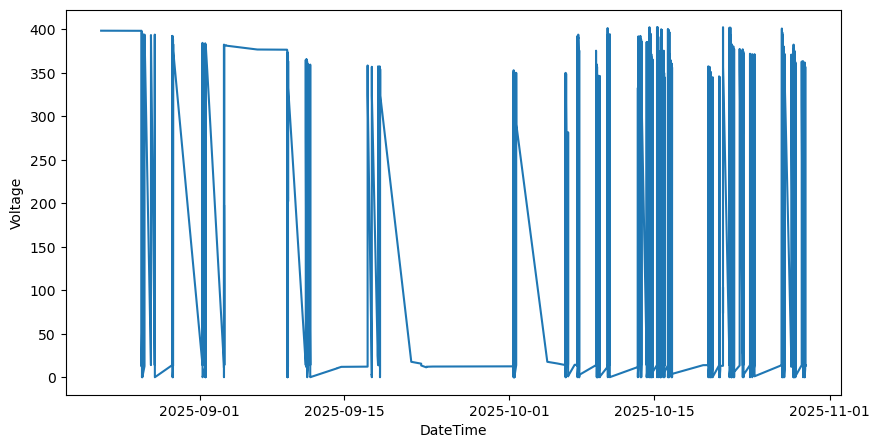

In [7]:
#plot SoC
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(route_vars_df['datetime'], route_vars_df['Voltage'])
plt.xlabel('DateTime')
plt.ylabel('Voltage')
plt.show()

In [8]:
# One-time adjustment: reduce SoC by 5 percentage points at every point
if 'SoC' not in route_vars_df.columns:
    raise KeyError("'SoC' column not found in route_vars_df")

route_vars_df['SoC'] = (route_vars_df['SoC'] - 5).clip(lower=0)
route_vars_df[['datetime', 'SoC']].head(15)

,datetime,SoC
0,2025-08-22 11:14:36.000000000,95.0
1,2025-08-22 11:14:36.006838784,95.0
2,2025-08-22 11:14:36.013677824,95.0
3,2025-08-22 11:14:36.020516608,95.0
4,2025-08-22 11:14:36.027355648,95.0
5,2025-08-22 11:14:36.034194432,95.0
6,2025-08-22 11:14:36.041033472,95.0
7,2025-08-22 11:14:36.047872256,95.0
8,2025-08-22 11:14:36.054711296,95.0
9,2025-08-22 11:14:36.061550080,95.0


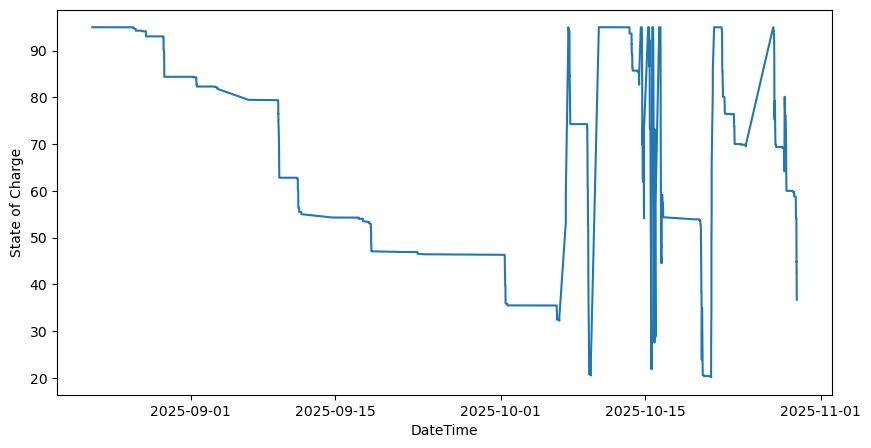

In [9]:
#plot SoC
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(route_vars_df['datetime'], route_vars_df['SoC'])
plt.xlabel('DateTime')
plt.ylabel('State of Charge')
plt.show()

In [10]:
processor.save()

route_vars_df.head(15)

Saved vars → processed_data\2020-11-16\vars.csv  (77851 rows)
Saved gps  → processed_data\2020-11-16\gps.csv  (38097 rows)
Saved route_vars → processed_data\2020-11-16\route_vars.csv  (274432 rows)


,datetime,latitude,longitude,Voltage,Current,Power,Energy,SoC,Procedencia
0,2025-08-22 11:14:36.000000000,9.908970,-84.094090,398.5,0.0,0.0,40.025833,95.0,AA
1,2025-08-22 11:14:36.006838784,9.908993,-84.094051,398.5,0.0,0.0,40.025833,95.0,AA
2,2025-08-22 11:14:36.013677824,9.909015,-84.094011,398.5,0.0,0.0,40.025833,95.0,AA
3,2025-08-22 11:14:36.020516608,9.909038,-84.093972,398.5,0.0,0.0,40.025833,95.0,AA
4,2025-08-22 11:14:36.027355648,9.909060,-84.093932,398.5,0.0,0.0,40.025833,95.0,AA
5,2025-08-22 11:14:36.034194432,9.909083,-84.093893,398.5,0.0,0.0,40.025833,95.0,AA
6,2025-08-22 11:14:36.041033472,9.909106,-84.093853,398.5,0.0,0.0,40.025833,95.0,AA
7,2025-08-22 11:14:36.047872256,9.909128,-84.093814,398.5,0.0,0.0,40.025833,95.0,AA
8,2025-08-22 11:14:36.054711296,9.909151,-84.093775,398.5,0.0,0.0,40.025833,95.0,AA
9,2025-08-22 11:14:36.061550080,9.909174,-84.093735,398.5,0.0,0.0,40.025833,95.0,AA


In [11]:
from GetFeatures import GetFeatures

feat = GetFeatures('config.yml', trip_date=processor.trip_date)
features_df = feat.run()
features_df.head(15)

Loaded 274432 points from processed_data\2020-11-16\route_vars.csv
  Total distance: 1255.32 km
  Segments: 12212 (target 100m)


KeyboardInterrupt: 

In [ ]:
# from geotab_processor import GeotabProcessor

# processor = GeotabProcessor('config.yml')
# from SelectRoutes import SelectRoutes

# router = SelectRoutes('config.yml', trip_date=processor.trip_date)

# # Define origin, destination, and optional waypoints (lat, lon)
# origin = (9.938431618596065, -84.04242771006302)
# destination = (9.923002036510496, -84.71348341082084)
# waypoints = [
#     (9.946408312880324, -84.1075270242855),
#     (9.998852155871559, -84.20965794599373),
#     (9.992262390787275, -84.32110029105247),
#     (9.986162599612205, -84.33666694801252),
#     (9.960107878275323, -84.35899648875584),
#     (9.94379395064879, -84.37234399566964),
#     (9.942631291491299, -84.3989518633456),
#     (9.906426084502195, -84.52176653130655),
#     (9.890576370313543, -84.56242082436405)

# ]

# route_df, travel = router.run(origin, destination, waypoints)
# print(travel)
# route_df.head(15)

In [ ]:
# from GetFeatures import GetFeatures

# feat_route = GetFeatures('config.yml', trip_date='2026-03-06', input_file='route_coords.csv')
# features_route_df = feat_route.run()
# features_route_df.head(15)

In [ ]:
# # resta 5% SoC a ruta plana 
# import pandas as pd
# rutaplana = pd.read_csv('ruta_plana.csv')
# rutaplana['SoC'] = (rutaplana['SoC'] - 5).clip(lower=0)
# rutaplana.to_csv('ruta_plana_1.csv', index=False)